# [1장 1강] - 실습: 문제 유형·데이터 분리·평가지표 리마인드

## 실습 배경

여러분은 병원 데이터팀에서 새 예측 모델의 평가 보고서를 검토하는 머신러닝 엔지니어입니다. 한 팀은 환자의 1년 뒤 질병 진행 정도를 예측하고 있고, 다른 팀은 세포핵 측정값으로 악성 종양을 탐지하고 있습니다. 두 팀 모두 높은 숫자 하나만 보고 모델을 배포하려 하지만, 회귀와 분류는 지표가 다르고 분할이나 임계값을 잘못 다루면 test 성능까지 의사결정에 섞일 수 있습니다.

이번 실습에서는 다음 질문에 답합니다.

1. 회귀 모델은 train 평균 기준 모델보다 실제로 나은가요?
2. 악성을 놓치지 않으려면 어떤 분류 지표를 함께 봐야 하나요?
3. Recall 정책을 만족하는 임계값을 어디에서 정하고, 어떤 모델과 함께 고정해야 하나요?

최종 결과는 모델 카드의 평가 항목으로 사용할 수 있는 짧은 보고서로 정리합니다.

## 실습 목표

- 회귀와 분류 문제를 구분하고 문제별 핵심 지표를 계산할 수 있습니다.
- train·validation·test의 역할을 설명하고 원본 인덱스가 겹치지 않는지 검증할 수 있습니다.
- 회귀 모델을 train 평균 기준 모델과 비교할 수 있습니다.
- 악성을 양성 클래스로 두고 Accuracy·Precision·Recall·F1·ROC-AUC·AP를 해석할 수 있습니다.
- validation Recall 정책으로 임계값을 선택하고 같은 fitted 모델과 함께 test에 적용할 수 있습니다.
- test를 다시 선택에 사용하지 않는 이유를 평가 보고서에 설명할 수 있습니다.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor

SEED = 42


def assert_disjoint(*frames):
    """여러 분할(train/valid/test 등)의 원본 인덱스가 서로 겹치지 않는지 확인합니다.

    같은 샘플이 두 분할에 동시에 들어가면 데이터 누수(leakage)가 발생하므로,
    분할 직후 이 함수로 검증해 두면 안전합니다. 겹치는 인덱스가 있으면
    AssertionError를 던지며 멈춥니다.

    Args:
        *frames: 인덱스를 가진 DataFrame/Series 여러 개 (개수 제한 없음).
    """
    # 각 분할에서 인덱스만 뽑아 집합(set)으로 변환.
    # 집합으로 만들면 교집합 여부를 빠르게(O(1) 평균) 확인할 수 있음.
    index_sets = [set(frame.index) for frame in frames]

    # 모든 분할의 '쌍'을 골라 하나씩 비교.
    for i in range(len(index_sets)):
        # j는 i보다 뒤쪽 인덱스만 -> 같은 쌍을 중복 검사하지 않고,
        # 자기 자신(i==j)과도 비교하지 않기 위함.
        for j in range(i + 1, len(index_sets)):
            # isdisjoint(): 두 집합의 교집합이 비어 있으면 True.
            # 즉 겹치는 인덱스가 하나도 없어야 통과.
            # 겹치는 게 있으면 여기서 AssertionError 발생.
            assert index_sets[i].isdisjoint(index_sets[j])

#====================diabetes====================
diabetes = load_diabetes(as_frame=True)
# type(diabetes) #sklearn.utils._bunch.Bunch
# 반환된 diabetes는 딕셔너리처럼 .data, .target 등을 담은 Bunch라는 객체

# 0단계: features와 target으로 분리
X_reg = diabetes.data
y_reg = diabetes.target
print(X_reg.shape, y_reg.shape) #(442, 10) (442,)

# 1 단계: 전체를 train(60%) + temp(40%)로 분할
X_reg_train, X_reg_temp, y_reg_train, y_reg_temp = train_test_split(
    X_reg, y_reg,
    test_size = 0.4,
    random_state = SEED
)
# 입력한 데이터 순서대로 train, test 데이터를 각각 순서대로 반환
print(f"442의 60% = {442 * 60/100}, train: {X_reg_train.shape}") # 442의 60% = 265.2, train: (265, 10)
print(f"442의 40% = {442 * 40/100}, temp: {X_reg_temp.shape}") # 442의 40% = 176.8, temp: (177, 10)

# 2 단계:: temp(40%)를 valid(20%) + test(20%)로 분할
X_reg_valid, X_reg_test, y_reg_valid, y_reg_test = train_test_split(
    X_reg_temp, y_reg_temp,
    test_size = 0.5,
    random_state=SEED
)
print(f"442의 20% = {442 * 20/100}, valid: {X_reg_valid.shape}, test: {X_reg_test.shape}")
# 442의 20% = 88.4, valid: (88, 10), test: (89, 10)

assert_disjoint(X_reg_train, X_reg_valid, X_reg_test)

#====================breast cancer====================
breast = load_breast_cancer(as_frame=True)

# 0단계: featrures와 target으로 분리
X_cls = breast.data
y_cls = (breast.target == 0).astype(int)
# True/False 배열을 정수로 변환. 즉 0값을 1로 반환, 1값을 0으로 반환

# 1단계: train와 temp로 분리
X_cls_train, X_cls_temp, y_cls_train, y_cls_temp = train_test_split(
    X_cls, y_cls,
    test_size = 0.4,
    stratify = y_cls, # 각 분할의 클래스 비율을 원본과 똑같이 맞춰서 쪼개줌
    random_state = SEED
)
X_cls.shape # (569, 30), 60% = 341.4, 40% = 227.6, 20% = 113.8
X_cls_train.shape # (341, 30)
X_cls_temp.shape # (228, 30)

# 2단계: temp를 valid와 test로 분리
X_cls_valid, X_cls_test, y_cls_valid, y_cls_test = train_test_split(
    X_cls_temp, y_cls_temp,
    test_size = 0.5,
    stratify = y_cls_temp, # 각 분할의 클래스 비율을 원본과 똑같이 맞춰서 쪼개줌
    random_state = SEED
)
X_cls_valid.shape # (114, 30)
X_cls_test.shape # (114, 30)


assert_disjoint(X_cls_train, X_cls_valid, X_cls_test)

y_cls.mean() # np.float64(0.37258347978910367)
y_cls_train.mean() # np.float64(0.3724340175953079)
y_cls_valid.mean() # np.float64(0.37719298245614036)
y_cls_test.mean() # np.float64(0.3684210526315789)

(442, 10) (442,)
442의 60% = 265.2, train: (265, 10)
442의 40% = 176.8, temp: (177, 10)
442의 20% = 88.4, valid: (88, 10), test: (89, 10)


np.float64(0.3684210526315789)

## 필수 1. 회귀 모델을 기준 모델과 비교하기

### 문제 1-1: Diabetes 회귀 평가 보고서 작성
- 질병 진행도 예측팀은 Linear Regression의 validation RMSE만 보고 모델이 충분히 좋다고 주장합니다. 하지만 RMSE의 크기만으로는 개선 여부를 판단하기 어렵습니다.
- train target 평균만 반복해서 예측하는 기준 모델을 만들고 같은 validation에서 비교하세요.

1. `StandardScaler → LinearRegression` Pipeline을 train에 학습하세요.
2. validation MAE·RMSE·R²를 계산하세요.
3. `y_reg_train.mean()`만 예측하는 기준 모델의 같은 지표를 계산하세요.
4. 세 분할의 원본 인덱스가 서로 겹치지 않는지 다시 확인하세요.
5. 모델 RMSE가 기준 모델보다 작은지 assertion으로 검증하세요.
6. 어떤 지표에서 얼마나 개선되었는지 2~3문장으로 해석하세요.

In [2]:
# 1. `StandardScaler → LinearRegression` Pipeline을 train에 학습하세요.
# 0단계: 도구 불러오기
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression

# 1단계: train 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_reg_train) # (데이터 − 평균) / 표준편차
# fit(train으로 평균·표준편차를 구해 scaler 안에 저장) + transform(그 기준으로 train을 표준화).

# 2 단계: valid 표준화
X_valid_scaled = scaler.transform(X_reg_valid) # 저장된 train 기준으로 변환
# test의 평균을 아는 것 자체가 미래를 훔쳐보는 누수이다
# 모델이 train의 평균으로 값을 조정했으니, test도 같은 잣대를 대야 한다
# test는 처음 보는 데이터이기 때문에 Train이 정한 좌표계에서 벗어나는 것이 현실의 반영이다.


# 3 단계: 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train_scaled, y_reg_train)

print(f"model.coef_: \n{model.coef_}\n")      # weight = coefficient (계수)
print(f"model.intercept_: \n{model.intercept_}\n") # bias = intercept (절편)

# 4단계: 모델 예측
pred_valid = model.predict(X_valid_scaled)

# 2. validation MAE·RMSE·R²를 계산하세요.
# 5단계: 지표 계산
mae = mean_absolute_error(y_reg_valid, pred_valid)
mse = mean_squared_error(y_reg_valid, pred_valid)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_valid, pred_valid)
# print(f"MAE: {mae}")
# print(f"MSE: {mse}")
# print(f"RMSE: {rmse}")
# print(f"R2: {r2}")


# 3. `y_reg_train.mean()`만 예측하는 기준 모델의 같은 지표를 계산하세요.
# baseline_value = y_reg_train.mean()
# baseline_value # np.float64(151.02641509433963)
# pred_valid_baseline = np.full(shape=len(y_reg_valid), fill_value=baseline_value)
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_reg_train, y_reg_train)
pred_valid_baseline = dummy.predict(X_reg_valid)

mae_base = mean_absolute_error(y_reg_valid, pred_valid_baseline)
mse_base = mean_squared_error(y_reg_valid, pred_valid_baseline)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_reg_valid, pred_valid_baseline)

print(f"MAE: {mae_base} vs {mae}")
print(f"MSE: {mse_base} vs {mse}")
print(f"RMSE: {rmse_base} vs {rmse}")
print(f"R2: {r2_base} vs {r2}")

# 4. 세 분할의 원본 인덱스가 서로 겹치지 않는지 다시 확인하세요.
assert_disjoint(X_cls_train, X_cls_valid, X_cls_test)

# 5. 모델 RMSE가 기준 모델보다 작은지 assertion으로 검증하세요.
assert rmse < rmse_base, f"모델의 RMSE가 baseline의 RMSE 보다 작음: {rmse} >= {rmse_base}"

# 6. 어떤 지표에서 얼마나 개선되었는지 2~3문장으로 해석하세요.
# MAE: 67.51616638078903 vs 38.22127405114379
# MSE: 5800.553313537655 vs 2415.692269896901
# RMSE: 76.1613636533489 vs 49.14969247001349
# R2: -0.006181543619704355 vs 0.5809667034070141

# 평균만 예측하는 baseline 대비, MAE가 67.5에서 38.2로 줄어 환자당 평균 오차를 약 29점 낮췄다.
# R2도 0.581로 올라, 평균 예측이 남기던 오차의 약 58%를 줄였다.
# 환자마다 진행도가 다른 그 "다름(변동)"을 평균 모델은 하나도 못 맞혔지만 선형회귀는 피처를 이용해 58% 만큼 맞혀냈다.

model.coef_: 
[  0.85123913 -10.78705929  28.35338275  17.35952702 -31.57426388
  16.92370006   0.69631007   6.8214824   28.3586807    1.48736662]

model.intercept_: 
151.02641509433963

MAE: 67.51616638078903 vs 38.22127405114379
MSE: 5800.553313537655 vs 2415.692269896901
RMSE: 76.1613636533489 vs 49.14969247001349
R2: -0.006181543619704355 vs 0.5809667034070141


## 필수 2. 악성 종양 분류 지표를 함께 읽기

### 문제 2-1: 고정 임계값 지표와 순위 지표 비교
- 악성 종양 탐지팀은 Accuracy 하나만 보고 모델을 승인하려고 합니다
- 악성을 놓치는 비용이 크므로 Recall을 포함한 임계값 지표와 ROC-AUC·AP 같은 순위 지표를 같은 validation에서 계산하세요.

### 수행해야 할 작업
1. `StandardScaler → LogisticRegression` Pipeline을 train에 학습하세요.
2. `predict_proba()[:, 1]`로 악성 확률을 구하세요.
3. 임계값 0.5에서 Accuracy·Precision·Recall·F1을 계산하세요.
4. 확률로 ROC-AUC와 AP를 계산하세요.
5. 모든 지표가 0과 1 사이인지 assertion으로 확인하세요.
6. 임계값 지표와 순위 지표의 차이를 평가 보고에 작성하세요.

Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9302325581395349
F1 Score: 0.963855421686747

[[71  0]
 [ 3 40]]

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


ROC-AUC: 1.0
Average Precision: 1.0

모든 지표가 0과 1 사이에 있음


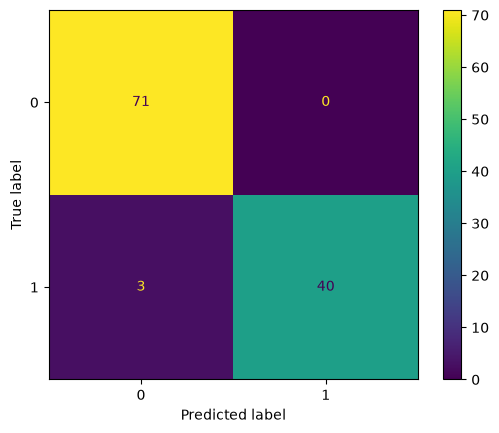

In [ ]:
# =====================================================================
# 1. `StandardScaler → LogisticRegression` Pipeline을 train에 학습하세요.
X_cls_train.shape # (341, 30)
X_cls_valid.shape # (114, 30)
X_cls_test.shape # (114, 30)

# 0 단계: 도구 불러오기
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression

# 1 단계: train 데이터 표준화
scaler2 = StandardScaler()
X_cls_train_scaled = scaler2.fit_transform(X_cls_train)

# 2 단계: valid 데이터를 train의 z-score로 표준화
X_cls_valid_scaled = scaler2.transform(X_cls_valid)

# 3단계: 모델 생성 및 학습
model2 = LogisticRegression()
model2.fit(X_cls_train_scaled, y_cls_train)

# print(f"model.coef_: \n{model2.coef_}") # 상관계수
# print(f"model.intercept_: \n{model2.intercept_}") # 절편

# =====================================================================
# 2. `predict_proba()[:, 1]`로 악성 확률을 구하세요.

# 4단계: 모델 예측
# LogisticRegression의 predict()는 0.5 임계값을 기본 적용
# target: 1 = malignant(악성), 0 = benign(양성) 으로 조정함

# pred_cls_valid = model2.predict(X_cls_valid_scaled)
pred_proba = model2.predict_proba(X_cls_valid_scaled)[:, 1]
pred_proba.shape #(114,)

# =====================================================================
# 3. 임계값 0.5에서 Accuracy·Precision·Recall·F1을 계산하세요.
threshold = 0.5
pred_custom = (pred_proba >= threshold).astype(int)

y_cls.mean() # np.float64(0.37258347978910367)
y_cls_train.mean() # np.float64(0.3724340175953079)
y_cls_valid.mean() # np.float64(0.37719298245614036)
y_cls_test.mean() # np.float64(0.3684210526315789)

# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
acc = accuracy_score(y_cls_valid, pred_custom)
prec = precision_score(y_cls_valid, pred_custom)
rec = recall_score(y_cls_valid, pred_custom)
f1 = f1_score(y_cls_valid, pred_custom)
print(f"Accuracy: {acc}") # 0.9736842105263158
print(f"Precision: {prec}") # 1.0
print(f"Recall: {rec}") # 0.9302325581395349
print(f"F1 Score: {f1}") # 0.963855421686747

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(f"\n{confusion_matrix(y_cls_valid, pred_custom)}")
print(f"\n{classification_report(y_cls_valid, pred_custom)}")

ConfusionMatrixDisplay.from_predictions(y_cls_valid, pred_custom)

# =====================================================================
# 4. 확률로 ROC-AUC와 AP를 계산하세요.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
# 데이터에 실제로 존재하는 확률값들을 기준으로 임계값을 잡는다

# 3개의 배열을 튜플로 반환
# fpr, tpr, thr = roc_curve(y_cls_valid, pred_proba)
roc_auc = roc_auc_score(y_cls_valid, pred_proba)
print(f"\nROC-AUC: {roc_auc}")

from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, thresholds = precision_recall_curve(y_cls_valid, pred_proba)
ap = average_precision_score(y_cls_valid, pred_proba)
print(f"Average Precision: {ap}")
# plt.plot(recall, precision)
# plt.show()

# =====================================================================
# 5. 모든 지표가 0과 1 사이인지 assertion으로 확인하세요.
for value in (acc, prec, rec, f1, roc_auc, ap):
    assert 0 <=  value <= 1
print(f"\n모든 지표가 0과 1 사이에 있음")

# =====================================================================
# 6. 임계값 지표와 순위 지표의 차이를 평가 보고에 작성하세요.

# 임계값 지표: (임계값을 하나 정해야 계산되는 지표) Accuracy, Precision, Recall, F1
# Recision은 1, Recall은 0.93, F1-score는 0.96을 기록했다.
# 양성 예측 후 음성인 값(오탐)은 없었으나, 음성으로 예측했으나 양성이었던(놓치는) 경우가 3건 발생했다.

# 순위 지표: (임계값과 무관하게 계산되는 지표) ROC-AUC, Average Precision
# 모델의 확률 순위는 양성과 음성을 확률로 완벽하게 갈라놨지만 임계값 0.5에서 양성을 3개 놓쳤다.
# 모든 양성이 모든 음성보다 높은 확률을 받았다. (오탐이 없었다.)
# 암진단 모델인 걸 감안하여 Recall을 끌어올릴 필요가 있으며 적절한 임계값을 고르면 Precision 손실을 최소화하면서 Recall을 높일 여지가 있다.


## 심화 1. Recall 정책으로 임계값 선택하기

### 문제 3-1: fitted 모델과 임계값을 한 쌍으로 고정
- 운영 정책은 validation Recall 0.90 이상인 후보 중 F1이 가장 높은 임계값을 요구합니다.
- 정책을 만족하는 임계값이 없으면 기준을 몰래 낮추지 말고 실패를 보고해야 합니다.
- 임계값을 선택한 뒤에는 그 확률을 만든 fitted clf와 임계값을 함께 고정하여 test를 한 번 평가하세요.

### 수행해야 할 작업
1. 0.05부터 0.95까지 0.01 간격의 임계값 표를 만드세요.
2. validation Recall 0.90 이상인 행만 남기세요.
3. F1, Precision, 임계값 순으로 동률을 처리하세요.
4. 후보가 없으면 `RuntimeError`를 발생시키세요.
5. fitted `clf`를 재학습하지 않고 test 악성 확률을 계산하세요.
6. test AP·Precision·Recall·F1을 출력하고 결과를 다시 선택에 사용하지 않는 이유를 설명하세요.

In [ ]:
# 1. 0.05부터 0.95까지 0.01 간격의 임계값 표를 만드세요.
thresholds = np.arange(0.05, 0.95 + 0.01, 0.01)

rows = []
for h in thresholds:
    pred = (pred_proba >= h).astype(int)
    rows.append({
        "threshold": h,
        "recall": recall_score(y_cls_valid, pred),
        "precision": precision_score(y_cls_valid, pred),
        "f1": f1_score(y_cls_valid, pred)
    })

table = pd.DataFrame(rows)
table

# 2. validation Recall 0.90 이상인 행만 남기세요.
table_cut = table[table["recall"] >= 0.9]
table_cut

# 3. F1, Precision, 임계값 순으로 동률을 처리하세요.
# 임계값이 낮을수록 Recall에 유리하니 임계값을 오름차순으로
# F1 높은 순 → 같으면 Precision 높은 순 → 그것도 같으면 임계값 낮은 순
table_sort = table_cut.sort_values(
    by=["f1", "precision", "threshold"], 
    ascending=[False, False, True]
    )
table_sort

# 4. 후보가 없으면 `RuntimeError`를 발생시키세요.
if table_cut.empty:
    raise RuntimeError("Recall 0.90 이상을 만족하는 임계값이 없습니다.")

# 5. fitted `clf`를 재학습하지 않고 test 악성 확률을 계산하세요.
# clf -> classification, fitted clf -> 이미 학습된 모델
X_cls_test_scaled = scaler2.transform(X_cls_test)
test_pred_proba = model2.predict_proba(X_cls_test_scaled)[:, 1]
chosen_threshold = 0.26
test_pred = (test_pred_proba >= chosen_threshold).astype(int)

# 6. test AP·Precision·Recall·F1을 출력하고 결과를 다시 선택에 사용하지 않는 이유를 설명하세요.
ap_test = average_precision_score(y_cls_test, test_pred_proba)
prec_test = precision_score(y_cls_test, test_pred)
rec_test = recall_score(y_cls_test, test_pred)
f1_test = f1_score(y_cls_test, test_pred)

print(f"test의 AP: {ap_test}")
print(f"test의 Precision: {prec_test}")
print(f"test의 Recall: {rec_test}")
print(f"test의 F1: {f1_test}")

# test를 보고 임계값을 다시 조정하면 test가 더 이상 처음 보는 데이터가 아니게 된다.
# 그러면 test 성능이 실제 배포 성능보다 부풀려진다.

test의 AP: 0.9919914842274095
test의 Precision: 0.975609756097561
test의 Recall: 0.9523809523809523
test의 F1: 0.963855421686747
